In [4]:
# Cell 0: Set working directory to project root (run this first in every new notebook)
import os

# Change to project root — update this path to match your system
os.chdir(r"C:\Users\1abhi\Downloads\NON-AARTI\Sign_Language_to_text&Audio")

# Verify
print("Working directory:", os.getcwd())
print("Train subset exists:", os.path.exists("data/asl_alphabet_train_subset"))
print("Test split exists:", os.path.exists("data/asl_alphabet_test_split"))

Working directory: C:\Users\1abhi\Downloads\NON-AARTI\Sign_Language_to_text&Audio
Train subset exists: True
Test split exists: True


In [5]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, Input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# Paths
TRAIN_SUBSET_DIR = "data/asl_alphabet_train_subset"
TEST_SPLIT_DIR   = "data/asl_alphabet_test_split"

# Configuration — 96x96 for MobileNetV2
IMG_SIZE    = 96
BATCH_SIZE  = 32
NUM_CLASSES = 29
EPOCHS      = 20

In [6]:
# Cell 2: Create data generators (same augmentation strategy as Phase 3, new IMG_SIZE)
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    validation_split=0.15
)

train_generator = train_datagen.flow_from_directory(
    TRAIN_SUBSET_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val_generator = train_datagen.flow_from_directory(
    TRAIN_SUBSET_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    TEST_SPLIT_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print("Train samples:", train_generator.samples)
print("Val samples:", val_generator.samples)
print("Test samples:", test_generator.samples)

Found 29580 images belonging to 29 classes.
Found 5220 images belonging to 29 classes.
Found 2900 images belonging to 29 classes.
Train samples: 29580
Val samples: 5220
Test samples: 2900


In [7]:
# Cell 3: Load MobileNetV2 base (without top classification layers)
base_model = MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,      # exclude ImageNet classification head (1000-class Dense layer)
    weights='imagenet'      # load pretrained ImageNet weights (downloads ~14MB first time)
)

# Freeze all base model layers — we don't want to overwrite pretrained features yet
base_model.trainable = False

print("Base model layers:", len(base_model.layers))
print("Base model trainable weights:", len(base_model.trainable_weights))

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Base model layers: 154
Base model trainable weights: 0


In [8]:
# Cell 4: Build transfer learning model
inputs = Input(shape=(IMG_SIZE, IMG_SIZE, 3))

# Pass inputs through frozen MobileNetV2 base
x = base_model(inputs, training=False)  
# training=False keeps BatchNorm layers in inference mode even during our training
# This is critical — we don't want frozen BN layers updating their running statistics

# GlobalAveragePooling instead of Flatten — averages spatial dimensions, far fewer params
x = GlobalAveragePooling2D()(x)

# Custom classification head
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)

# Output layer: 29 ASL classes
outputs = Dense(NUM_CLASSES, activation='softmax')(x)

model_transfer = Model(inputs, outputs)
model_transfer.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 29)             │         3,741 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,425,693 (9.25 MB)

 Trainable params: 167,709 (655.11 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [9]:
# Cell 5: Compile and train Phase 1 — frozen base, train head only
model_transfer.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_phase1 = [
    EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6),
    ModelCheckpoint(
        filepath="models/mobilenet_phase1_best.keras",
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

print("Training Phase 1: frozen base, head only...")
history_phase1 = model_transfer.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    callbacks=callbacks_phase1
)


Training Phase 1: frozen base, head only...


c:\Users\1abhi\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
925/925 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step - accuracy: 0.5275 - loss: 1.6391
Epoch 1: val_accuracy improved from -inf to 0.72816, saving model to models/mobilenet_phase1_best.keras
925/925 ━━━━━━━━━━━━━━━━━━━━ 194s 203ms/step - accuracy: 0.5276 - loss: 1.6385 - val_accuracy: 0.7282 - val_loss: 0.8907 - learning_rate: 0.0010
Epoch 2/20
925/925 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step - accuracy: 0.8196 - loss: 0.5604
Epoch 2: val_accuracy improved from 0.72816 to 0.74559, saving model to models/mobilenet_phase1_best.keras
925/925 ━━━━━━━━━━━━━━━━━━━━ 181s 195ms/step - accuracy: 0.8196 - loss: 0.5604 - val_accuracy: 0.7456 - val_loss: 0.7914 - learning_rate: 0.0010
Epoch 3/20
925/925 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step - accuracy: 0.8583 - loss: 0.4346
Epoch 3: val_accuracy improved from 0.74559 to 0.74808, saving model to models/mobilenet_phase1_best.keras
925/925 ━━━━━━━━━━━━━━━━━━━━ 191s 207ms/step - accuracy: 0.8583 - loss: 0.4346 - val_accuracy: 0.7481 - val_loss: 0.8089 - learn

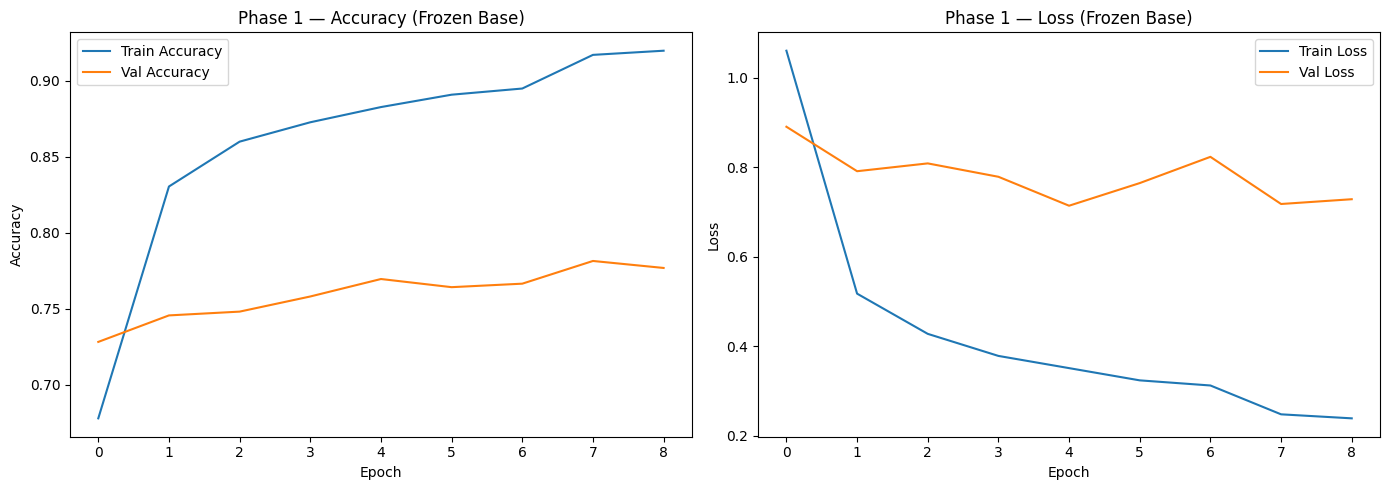

In [10]:
# Cell 6: Plot Phase 1 training curves
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history_phase1.history['accuracy'], label='Train Accuracy')
plt.plot(history_phase1.history['val_accuracy'], label='Val Accuracy')
plt.title('Phase 1 — Accuracy (Frozen Base)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_phase1.history['loss'], label='Train Loss')
plt.plot(history_phase1.history['val_loss'], label='Val Loss')
plt.title('Phase 1 — Loss (Frozen Base)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [11]:
# Cell 7: Fine-tuning — unfreeze top 30 layers of MobileNetV2
# Why top 30 only: lower layers detect universal features (edges, textures)
# that are useful for any vision task — no need to retrain these.
# Upper layers detect more task-specific features — these benefit from slight adaptation.

base_model.trainable = True

# Freeze all layers except the top 30
for layer in base_model.layers[:-30]:
    layer.trainable = False

# Count trainable params after partial unfreeze
trainable_count = sum([tf.size(w).numpy() for w in model_transfer.trainable_weights])
print(f"Trainable parameters after unfreeze: {trainable_count:,}")

Trainable parameters after unfreeze: 1,694,109


In [12]:
# Cell 8: Recompile with very small learning rate for fine-tuning
# Critical: use a much smaller LR (10x-100x smaller than Phase 1)
# to avoid catastrophic forgetting — we want to gently nudge pretrained
# weights, not overwrite them completely

model_transfer.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),  # 10x smaller than Phase 1
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_phase2 = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7),
    ModelCheckpoint(
        filepath="models/mobilenet_phase2_best.keras",
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

print("Training Phase 2: fine-tuning top 30 layers...")
history_phase2 = model_transfer.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15,              # fewer epochs — fine-tuning converges faster
    callbacks=callbacks_phase2
)

Training Phase 2: fine-tuning top 30 layers...
Epoch 1/15
925/925 ━━━━━━━━━━━━━━━━━━━━ 0s 202ms/step - accuracy: 0.7810 - loss: 0.7976
Epoch 1: val_accuracy improved from -inf to 0.73985, saving model to models/mobilenet_phase2_best.keras
925/925 ━━━━━━━━━━━━━━━━━━━━ 234s 240ms/step - accuracy: 0.7811 - loss: 0.7972 - val_accuracy: 0.7398 - val_loss: 0.9605 - learning_rate: 1.0000e-04
Epoch 2/15
925/925 ━━━━━━━━━━━━━━━━━━━━ 0s 208ms/step - accuracy: 0.9208 - loss: 0.2415
Epoch 2: val_accuracy improved from 0.73985 to 0.82203, saving model to models/mobilenet_phase2_best.keras
925/925 ━━━━━━━━━━━━━━━━━━━━ 227s 245ms/step - accuracy: 0.9208 - loss: 0.2415 - val_accuracy: 0.8220 - val_loss: 0.6173 - learning_rate: 1.0000e-04
Epoch 3/15
925/925 ━━━━━━━━━━━━━━━━━━━━ 0s 205ms/step - accuracy: 0.9411 - loss: 0.1814
Epoch 3: val_accuracy improved from 0.82203 to 0.82490, saving model to models/mobilenet_phase2_best.keras
925/925 ━━━━━━━━━━━━━━━━━━━━ 222s 240ms/step - accuracy: 0.9411 - loss: 0

In [13]:
# Cell 9: Final evaluation on test set — compare with custom CNN baseline
test_loss, test_accuracy = model_transfer.evaluate(test_generator, verbose=0)
print(f"\nMobileNetV2 Test Accuracy:  {test_accuracy*100:.2f}%")
print(f"Custom CNN Test Accuracy:   ~80.69% (Phase 6 baseline)")
print(f"Improvement:                +{(test_accuracy*100 - 80.69):.2f}%")


MobileNetV2 Test Accuracy:  94.76%
Custom CNN Test Accuracy:   ~80.69% (Phase 6 baseline)
Improvement:                +14.07%


In [14]:
# Cell 10: Save final transfer learning model + update class indices
model_transfer.save("models/asl_mobilenet_final.keras")
print("MobileNetV2 model saved.")

# class_indices stays the same (same dataset, same classes)
# but confirm it's saved for use in scripts
with open("models/class_indices.json", "r") as f:
    class_indices = json.load(f)
print("Class indices confirmed:", len(class_indices), "classes")

MobileNetV2 model saved.
Class indices confirmed: 29 classes
